In [1]:
# Import all necessary libraries
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from math import sqrt

# PfHedge imports
from pfhedge.instruments import Snowball
from pfhedge.stochastic.local_volatility import generate_local_volatility_process
from pfhedge.nn.modules.hedger import Hedger
from pfhedge.nn.modules.loss import EntropicRiskMeasure, ExpectedShortfall
from pfhedge.nn.modules.mlp import MultiLayerPerceptron

# Set random seed for reproducibility
torch.manual_seed(42)
print("Training dynamics experiment loaded successfully!")

Training dynamics experiment loaded successfully!


In [2]:
# 定义局部波动率函数（CEV模型）
def sigma_fn(time: torch.Tensor, spot: torch.Tensor) -> torch.Tensor:
    beta = 0.5
    sigma_0 = 0.2
    init_state = 100.0  # 初始价格
    moneyness = spot / init_state
    return sigma_0 * (moneyness ** (beta - 1)).clamp(min=0.01, max=1.0)

def generate_local_volatility_process_fixed(
    n_paths: int,
    n_steps: int,
    sigma_fn,
    init_state,
    dt: float = 1 / 250,
):
    """修复版本的局部波动率过程生成函数，避免原地操作"""
    import torch
    
    # 确保init_state是张量
    if not isinstance(init_state, torch.Tensor):
        init_state = torch.tensor(init_state, dtype=torch.float32)
    
    # 创建spot和volatility张量
    spot = torch.zeros(n_paths, n_steps)
    volatility = torch.zeros(n_paths, n_steps)
    
    # 设置初始值
    spot[:, 0] = init_state[0]
    
    # 生成时间序列
    time = dt * torch.arange(n_steps)
    
    # 生成随机数
    dw = torch.randn(n_paths, n_steps - 1) * sqrt(dt)
    
    # 逐步生成路径，避免原地操作
    for i_step in range(n_steps - 1):
        current_time = time[i_step]
        current_spot = spot[:, i_step]
        
        # 计算局部波动率
        if sigma_fn is not None:
            sigma = sigma_fn(current_time, current_spot)
        else:
            sigma = 0.2 * torch.ones_like(current_spot)
        
        # 存储波动率
        volatility[:, i_step] = sigma
        
        # 计算下一个价格，避免原地操作
        next_spot = current_spot * (1 + sigma * dw[:, i_step])
        spot[:, i_step + 1] = next_spot
    
    # 设置最后一个时间步的波动率
    if sigma_fn is not None:
        final_sigma = sigma_fn(time[-1], spot[:, -1])
    else:
        final_sigma = 0.2 * torch.ones(n_paths)
    volatility[:, -1] = final_sigma
    
    return spot, volatility

# 创建股票对象（使用Local Volatility）
class LocalVolStock:
    def __init__(self, cost, dt, sigma_fn):
        self.cost = cost
        self.dt = dt
        self.sigma_fn = sigma_fn
        self.spot = None
        self.volatility = None
        self.log_spot = None
        
    def simulate(self, n_paths, time_horizon=None, init_state=None):
        # 使用修复版本的Local Volatility生成函数
        if time_horizon is None:
            time_horizon = 1.0  # 默认1年
        
        if init_state is None:
            init_state = (100.0,)  # 默认初始价格
        
        # 修复：确保时间步数正确，加1确保包含初始状态
        n_steps = int(time_horizon / self.dt) + 1
        
        # 使用修复版本的函数
        spot, volatility = generate_local_volatility_process_fixed(
            n_paths, n_steps, self.sigma_fn, init_state, self.dt
        )
        
        self.spot = spot
        self.volatility = volatility
        self.log_spot = torch.log(spot)
        return self
    
    def is_listed(self, time: float) -> bool:
        """检查股票在给定时间是否上市"""
        return True
    
    def to(self, device=None, dtype=None, non_blocking=False):
        """设备迁移方法"""
        if self.spot is not None:
            self.spot = self.spot.to(device, dtype, non_blocking)
        if self.volatility is not None:
            self.volatility = self.volatility.to(device, dtype, non_blocking)
        if self.log_spot is not None:
            self.log_spot = self.log_spot.to(device, dtype, non_blocking)
        return self

print("Local Volatility股票类定义完成！")

Local Volatility股票类定义完成！


In [3]:
def create_basic_snowball():
    """Create a basic Snowball option for experimentation."""

    # Market parameters
    init_state = 100.0
    dt = 1 / 250  # Daily time steps
    cost = 1e-4

    # 创建股票
    stock = LocalVolStock(cost=cost, dt=dt, sigma_fn=sigma_fn)

    # Snowball parameters - 使用与原始文件完全相同的参数
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]
    
    derivative = Snowball(
        underlier=stock,
        notional=100.0,
        init_spot=init_state,
        strike=100.0,
        maturity=obs_days[-1] * dt,  # 使用与原始文件相同的maturity
        knockin_barrier=80.0,  # 20% below initial spot
        observations=[d * dt for d in obs_days],
        knockout_barriers=[100.0] * len(obs_days),  # At-the-money knock-out
        knockout_coupons=[0.5 * d / 250 for d in obs_days],  # Time-proportional coupons
        no_touch_coupon=0.05,  # 5% if never knocked out
        is_knocked_in=False,
    )

    return derivative, stock, init_state

print("Snowball期权创建函数定义完成！")

Snowball期权创建函数定义完成！


In [16]:
# Training parameters
fit_n_paths = 10000
fit_n_epochs = [1, 3, 5, 10, 15, 20, 30, 50, 70, 100]
loss = EntropicRiskMeasure(a=0.01)

# Features for Snowball hedging
features = [
    "log_moneyness",     # Current underlying price relative to strike
    "expiry_time",       # Time to expiration
    "volatility",        # Implied volatility
    "knocked_in",        # Whether barrier has been touched
    "prev_hedge"         # Previous hedge position
]

print("训练参数设置完成！")
print(f"训练路径数: {fit_n_paths}")
print(f"快照轮数: {fit_n_epochs}")
print(f"特征列表: {features}")

训练参数设置完成！
训练路径数: 10000
快照轮数: [1, 3, 5, 10, 15, 20, 30, 50, 70, 100]
特征列表: ['log_moneyness', 'expiry_time', 'volatility', 'knocked_in', 'prev_hedge']


In [18]:
# Create derivative
derivative, stock, init_state = create_basic_snowball()

print("Training hedger with progressive snapshots and learning rate scheduling...")

# Create hedger
model = MultiLayerPerceptron(n_layers=4, n_units=[32, 32, 32, 32])
hedger = Hedger(model, features, criterion=loss)

# 使用与原始文件完全相同的模式
init_spot = torch.tensor(init_state, requires_grad=True)

# 自定义训练函数，包含学习率调度
def fit_with_scheduler(hedger, derivative, n_epochs, n_paths, init_state, snapshots=None):
    """自定义训练函数，包含学习率调度"""
    from copy import deepcopy
    from tqdm import tqdm
    
    # 配置优化器
    optimizer = torch.optim.Adam(hedger.parameters(), lr=0.001)

    # 添加梯度裁剪，防止梯度爆炸
    torch.nn.utils.clip_grad_norm_(hedger.parameters(), max_norm=1.0)
    
    # 设置学习率调度器
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min',           # 监控损失下降
        factor=0.7,           # 学习率衰减因子
        patience=15,          # 10个epoch没有改善就降低学习率
        min_lr=1e-7       # 最小学习率
    )
    
    def compute_loss():
        base_loss = hedger.compute_loss(
            derivative,
            n_paths=n_paths,
            init_state=init_state,
        )
    
        l2_reg = 0.0001 * sum(p.pow(2.0).sum() for p in hedger.parameters())
    
        return base_loss + l2_reg
    
    history = []
    hedger_snapshots = []
    
    # 在训练循环开始前添加监控变量
    best_loss = float('inf')
    patience_counter = 0
    patience_limit = 30  # 30轮无改善就调整

    progress = tqdm(range(n_epochs), desc="Training with LR scheduling")
    for i in progress:
        # 训练步骤
        hedger.train()
        optimizer.zero_grad()
        loss = compute_loss()
        loss.backward()
        optimizer.step()
    
        # 验证步骤
        hedger.eval()
        val_loss = compute_loss()
        history.append(val_loss.item())
    
        # 更新学习率调度器
        scheduler.step(val_loss)
    
        # 监控Loss改善情况
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
    
        # 每10轮检查标准差
        if (i + 1) % 10 == 0:
            hedger.eval()
            derivative.simulate(n_paths=5000, init_state=init_state)
            pnl = hedger.compute_pnl(derivative, n_paths=5000, init_state=init_state)
            pnl_std = pnl.std().item()
        
            print(f"Epoch {i+1}: Loss={val_loss.item():.4f}, PnL_std={pnl_std:.4f}")
        
            # 如果达标就停止
            if pnl_std < 0.05:
                print(f"Target achieved! Stopping at epoch {i+1}")
                break
    
        # 如果30轮无改善，考虑调整
        if patience_counter >= patience_limit:
            print(f"Loss not improving for {patience_limit} epochs, consider adjustment")
            break
    
        # 更新进度条
        current_lr = optimizer.param_groups[0]['lr']
        progress.desc = f"Loss={val_loss.item():.4f}, LR={current_lr:.6f}"
    
        # 保存快照
        if snapshots is not None and (i + 1) in snapshots:
            hedger_snapshots.append(
                Hedger(deepcopy(hedger.model), hedger.inputs.features, criterion=hedger.criterion)
            )
    
    return history, hedger_snapshots + [hedger]

# 开始训练，包含学习率调度
history, hedgers = fit_with_scheduler(
    hedger,
    derivative,
    n_epochs=fit_n_epochs[-1],
    n_paths=fit_n_paths,
    init_state=(init_spot,),
    snapshots=fit_n_epochs[:-1]
)

print("训练完成！")
print(f"训练历史长度: {len(history)}")
print(f"保存的hedger数量: {len(hedgers)}")

Training hedger with progressive snapshots and learning rate scheduling...


Loss=5.7897, LR=0.001000:  10%|█         | 10/100 [00:40<06:16,  4.18s/it]

Epoch 10: Loss=5.7897, PnL_std=12.6092


Loss=5.7067, LR=0.001000:  20%|██        | 20/100 [01:19<05:24,  4.05s/it]

Epoch 20: Loss=5.7067, PnL_std=11.7404


...

Epoch 80: Loss=5.3337, PnL_std=8.8047


Loss=5.3280, LR=0.001000:  90%|█████████ | 90/100 [05:49<00:38,  3.82s/it]

Epoch 90: Loss=5.3280, PnL_std=8.1597


Loss=5.1027, LR=0.000700: 100%|██████████| 100/100 [06:25<00:00,  3.86s/it]

Epoch 100: Loss=5.1027, PnL_std=7.9127
训练完成！
训练历史长度: 100
保存的hedger数量: 10


In [19]:
# Get baseline PV for comparison
print("计算Monte Carlo基准价格...")
derivative.simulate(n_paths=100000, init_state=(init_spot,))
pv_basic = derivative.payoff().mean().item()
print(f"MC Truth Price: {pv_basic:.6f}")

计算Monte Carlo基准价格...
MC Truth Price: 4.950387


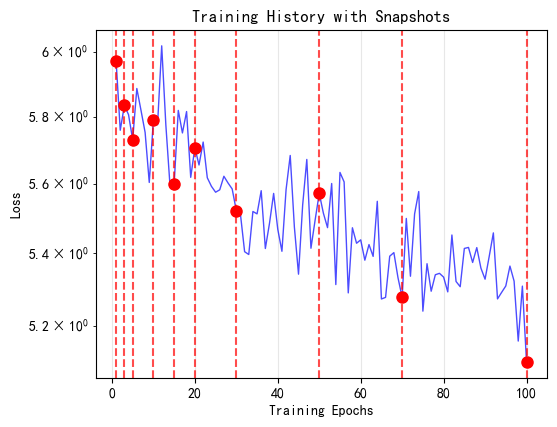

In [21]:
# Plot training history
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
# 显示完整的训练历史
plt.plot(range(1, len(history) + 1), history, 'b-', alpha=0.7, linewidth=1)
# 标记快照点
for epoch in fit_n_epochs:
    if epoch <= len(history):
        plt.axvline(x=epoch, color='red', linestyle='--', alpha=0.7)
        plt.plot(epoch, history[epoch-1], 'ro', markersize=8)

plt.xlabel("Training Epochs")
plt.ylabel("Loss")
plt.title("Training History with Snapshots")
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Evaluate hedger price at different training stages
print("\n计算不同训练阶段的hedger价格...")
prices = []
for i, h in enumerate(hedgers):
    print(f"  计算第 {i+1}/{len(hedgers)} 个快照的价格...")
    price = h.price(derivative, n_paths=50000, init_state=(init_spot,))
    prices.append(price)
    print(f"    Epoch {fit_n_epochs[i]} Price: {price:.6f}")

print("价格计算完成！")


计算不同训练阶段的hedger价格...
  计算第 1/10 个快照的价格...
    Epoch 1 Price: 5.867767
  计算第 2/10 个快照的价格...
    Epoch 3 Price: 5.735874
  计算第 3/10 个快照的价格...
    Epoch 5 Price: 5.794334
  计算第 4/10 个快照的价格...
    Epoch 10 Price: 5.772305
  计算第 5/10 个快照的价格...
    Epoch 15 Price: 5.665016
  计算第 6/10 个快照的价格...
    Epoch 20 Price: 5.675507
  计算第 7/10 个快照的价格...
    Epoch 30 Price: 5.491543
  计算第 8/10 个快照的价格...
    Epoch 50 Price: 5.424786
  计算第 9/10 个快照的价格...
    Epoch 70 Price: 5.297279
  计算第 10/10 个快照的价格...
    Epoch 100 Price: 5.247116
价格计算完成！


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

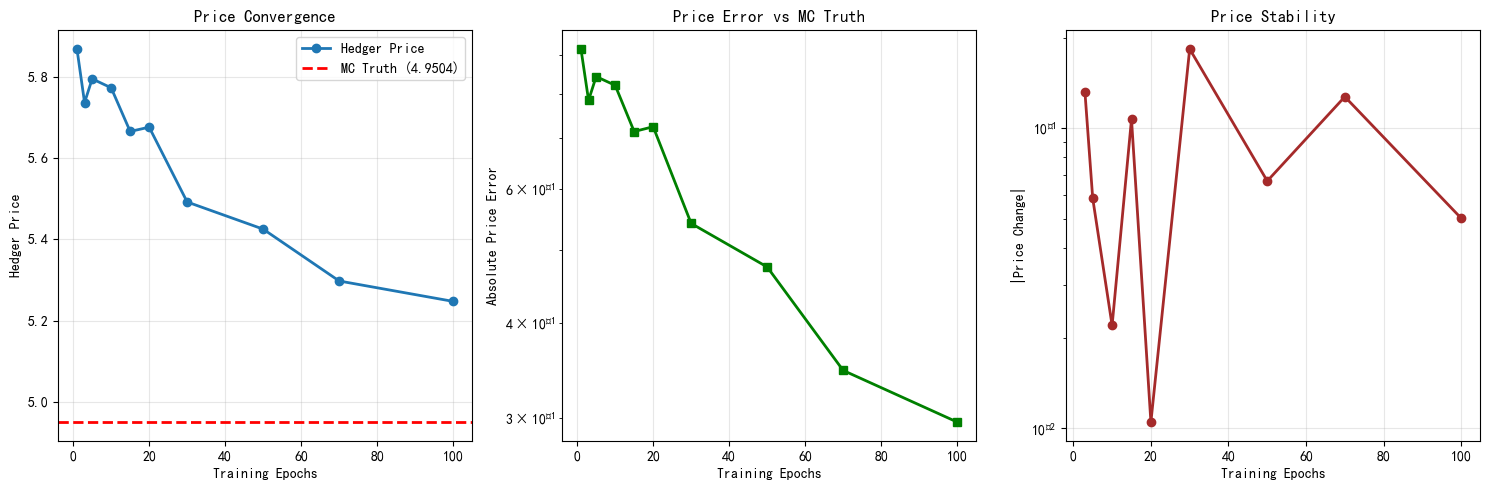

In [23]:
# 绘制价格收敛图
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
# 价格收敛曲线
plt.plot(fit_n_epochs, prices, 'o-', linewidth=2, markersize=6, label='Hedger Price')
plt.axhline(y=pv_basic, color='red', linestyle='--', linewidth=2, label=f'MC Truth ({pv_basic:.4f})')
plt.xlabel("Training Epochs")
plt.ylabel("Hedger Price")
plt.title("Price Convergence")
plt.legend()
plt.grid(True, alpha=0.3)

# 添加价格差异分析
plt.subplot(1, 3, 2)
price_errors = [abs(p - pv_basic) for p in prices]
plt.plot(fit_n_epochs, price_errors, 's-', linewidth=2, markersize=6, color='green')
plt.xlabel("Training Epochs")
plt.ylabel("Absolute Price Error")
plt.title("Price Error vs MC Truth")
plt.yscale('log')
plt.grid(True, alpha=0.3)

# 价格变化率
plt.subplot(1, 3, 3)
if len(prices) > 1:
    price_changes = [abs(prices[i] - prices[i-1]) for i in range(1, len(prices))]
    plt.plot(fit_n_epochs[1:], price_changes, 'brown', linewidth=2, marker='o')
plt.xlabel("Training Epochs")
plt.ylabel("|Price Change|")
plt.title("Price Stability")
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Analyze PnL distributions
print("\nPnL Distribution Analysis:")
print("-" * 30)

# Test PnL for different training stages
derivative.simulate(n_paths=fit_n_paths, init_state=(init_spot,))
pnls = []
for h in hedgers:
    pnl = h.compute_pnl(derivative, n_paths=fit_n_paths, init_state=(init_spot,))
    pnls.append(pnl)
    print(f"    Epoch {fit_n_epochs[len(pnls)-1]} - Mean PnL: {pnl.mean().item():.6f}, Std PnL: {pnl.std().item():.6f}")

print("PnL计算完成！")


PnL Distribution Analysis:
------------------------------
    Epoch 1 - Mean PnL: -5.013117, Std PnL: 13.374602
    Epoch 3 - Mean PnL: -4.975954, Std PnL: 13.450768
    Epoch 5 - Mean PnL: -5.064835, Std PnL: 12.795783
    Epoch 10 - Mean PnL: -5.005744, Std PnL: 12.695603
    Epoch 15 - Mean PnL: -4.724085, Std PnL: 12.342971
    Epoch 20 - Mean PnL: -4.908105, Std PnL: 11.738057
    Epoch 30 - Mean PnL: -4.786644, Std PnL: 10.763250
    Epoch 50 - Mean PnL: -4.911506, Std PnL: 9.797380
    Epoch 70 - Mean PnL: -4.845004, Std PnL: 9.066355
    Epoch 100 - Mean PnL: -4.842227, Std PnL: 7.863233
PnL计算完成！


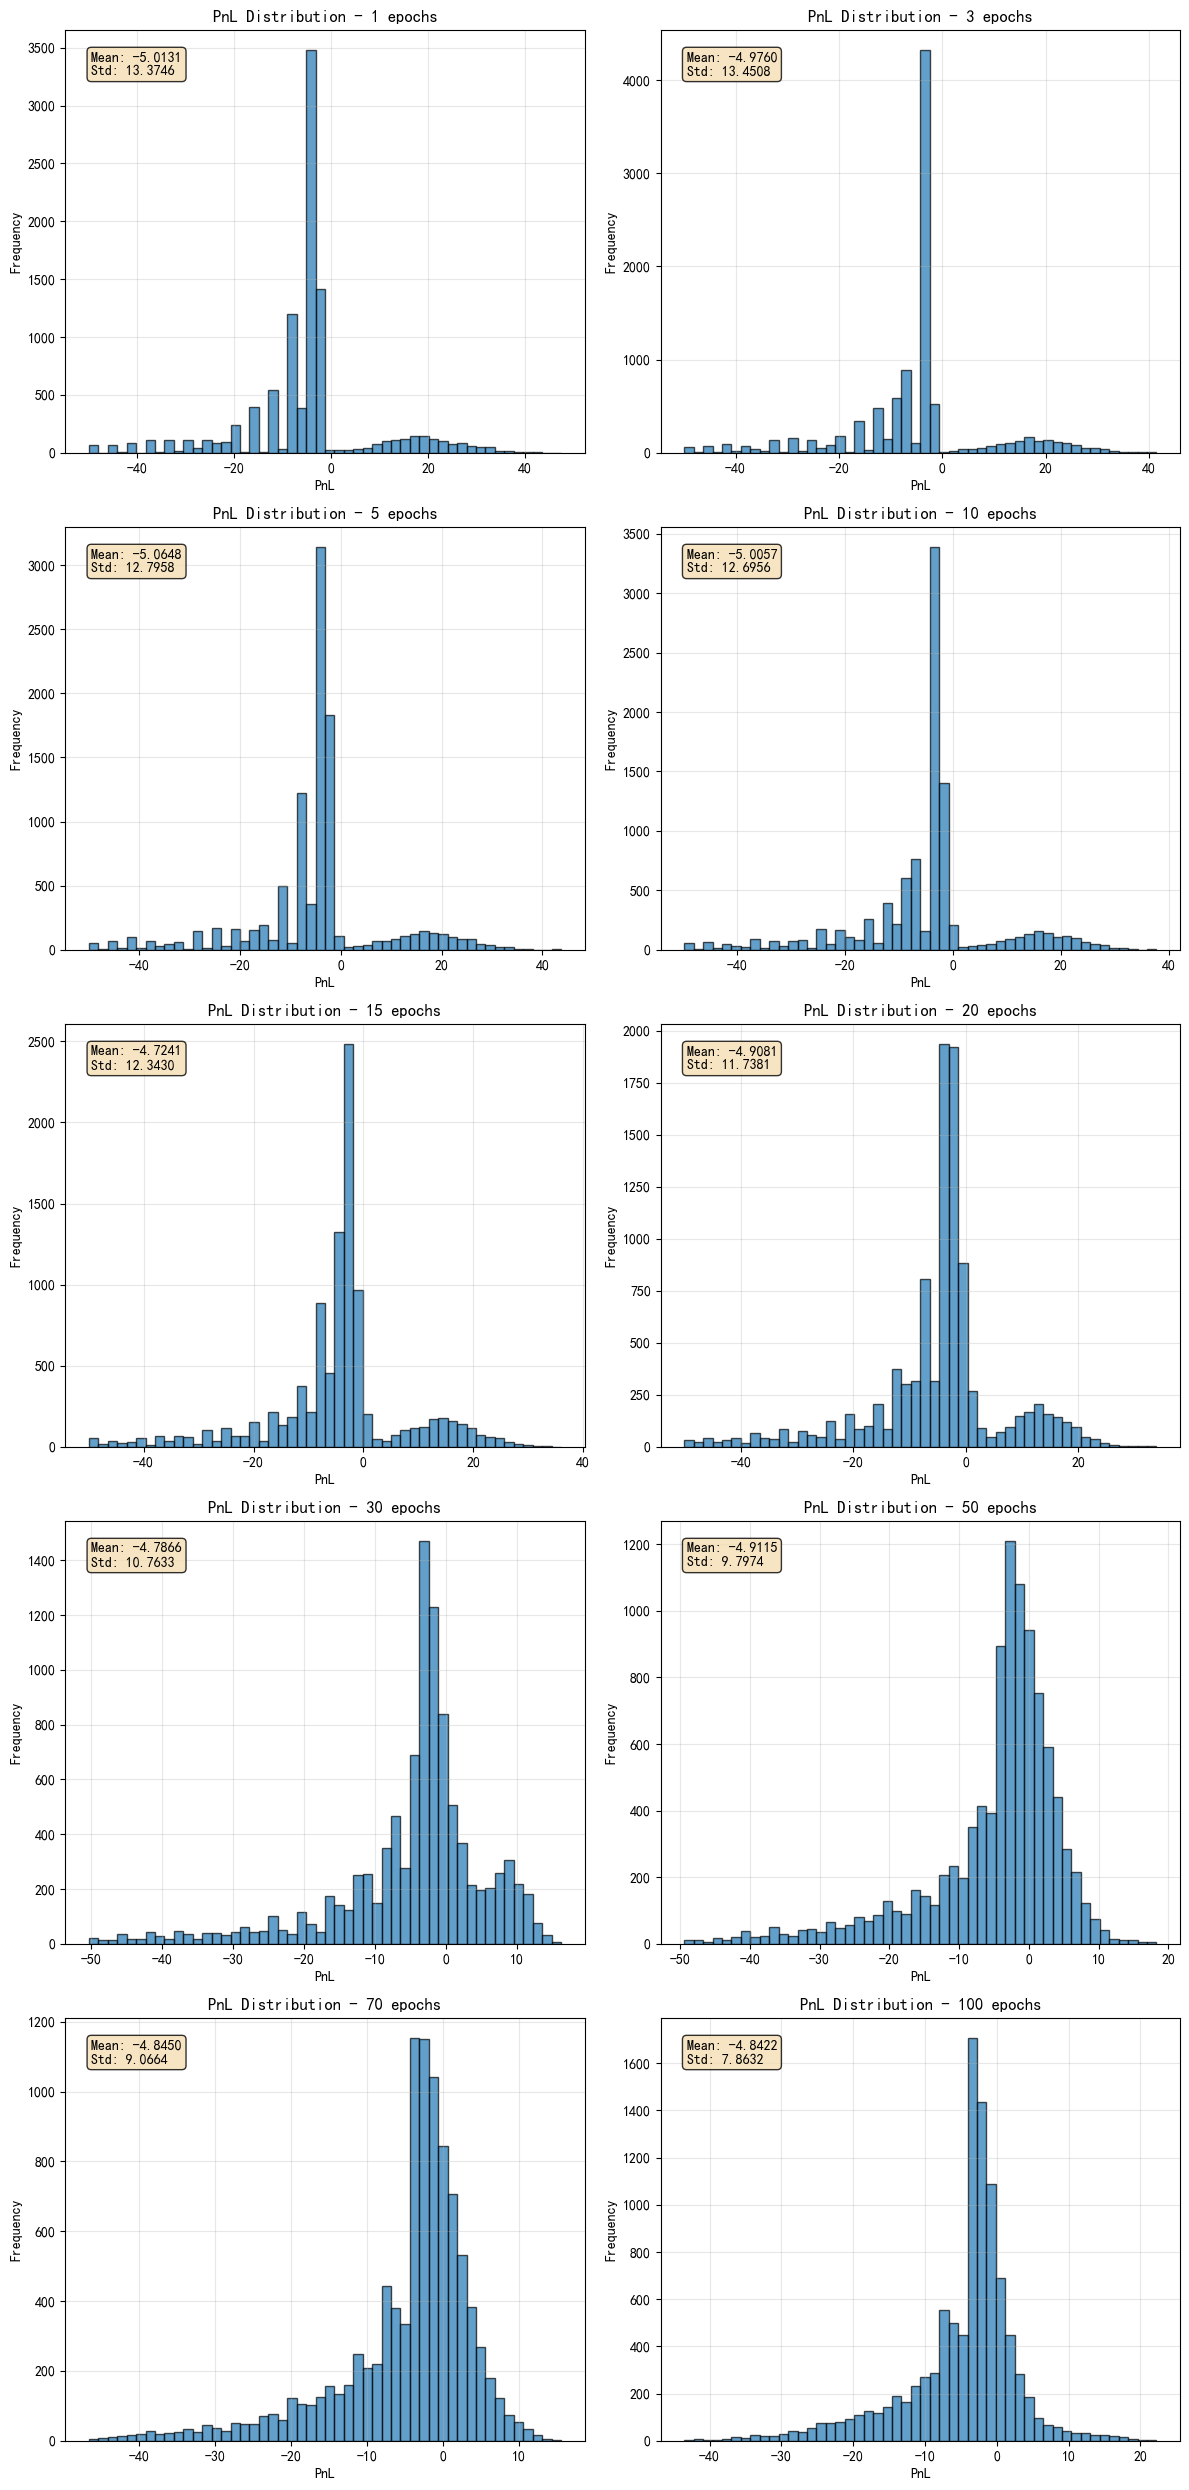

In [25]:
# Plot PnL distributions
n_row = (len(pnls) + 1) // 2
fig, axes = plt.subplots(n_row, 2, figsize=(12, 5 * n_row))
axes = axes.flatten() if n_row > 1 else [axes] if n_row == 1 else axes

for i, (pnl, epochs) in enumerate(zip(pnls, fit_n_epochs)):
    ax = axes[i]
    ax.hist(pnl.detach().numpy(), bins=50, alpha=0.7, edgecolor='black')
    ax.set_xlabel("PnL")
    ax.set_ylabel("Frequency")
    ax.set_title(f"PnL Distribution - {epochs} epochs")
    ax.grid(True, alpha=0.3)

    # Add statistics
    mean_pnl = pnl.mean().item()
    std_pnl = pnl.std().item()
    ax.text(0.05, 0.95, f'Mean: {mean_pnl:.4f}\nStd: {std_pnl:.4f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Hide empty subplots
for i in range(len(pnls), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [26]:
# 总结结果
print(f"\n=== 训练结果总结 ===")
print(f"训练轮数: {fit_n_epochs[-1]}")
print(f"保存的快照数量: {len(hedgers)}")
print(f"MC Truth Price: {pv_basic:.6f}")
print(f"最终Hedger Price: {prices[-1]:.6f}")
print(f"价格误差: {abs(prices[-1] - pv_basic):.6f}")
print(f"最终PnL均值: {pnls[-1].mean().item():.6f}")
print(f"最终PnL标准差: {pnls[-1].std().item():.6f}")

print("\n训练实验完成！")


=== 训练结果总结 ===
训练轮数: 100
保存的快照数量: 10
MC Truth Price: 4.950387
最终Hedger Price: 5.247116
价格误差: 0.296729
最终PnL均值: -4.842227
最终PnL标准差: 7.863233

训练实验完成！


中证500历史数据回测 - 局部波动率模型（使用预训练对冲器）
数据时间范围: 2020-03-11 00:00:00 到 2025-03-07 00:00:00
总交易日数: 1210
统一初始价格: 100.00
使用预训练对冲器（训练100个epoch）
蒙特卡洛价格: 4.871345
对冲器价格: 5.213547
价格差异: 0.342202


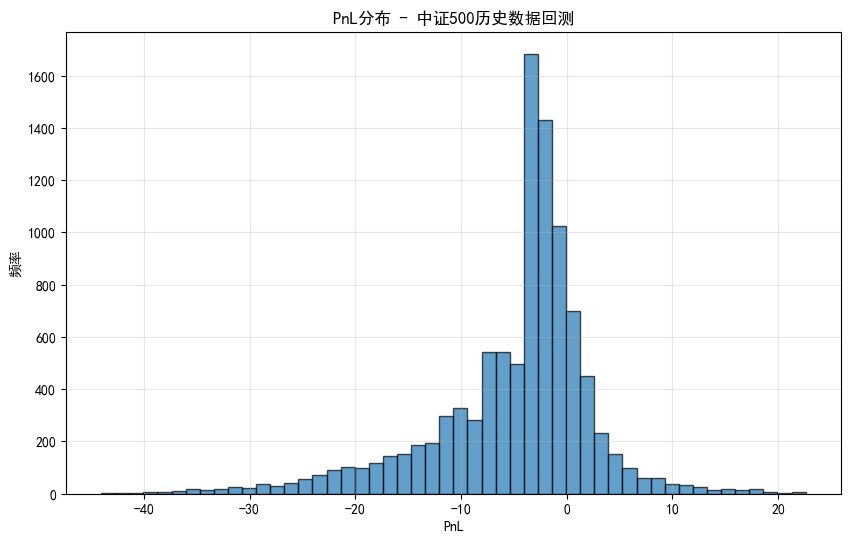


回测统计:
------------------------------
PnL均值: -4.986090
PnL标准差: 7.699938
最大盈利: 22.597765
最大亏损: -44.053993
VaR(95%): -20.701313


In [32]:
# 添加必要的导入
from pfhedge.instruments import BrownianStock
from datetime import datetime, timedelta

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

def load_csi500_data():
    """加载中证500历史数据"""
    df = pd.read_csv('csi500.csv')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')
    df = df.sort_values('Date').reset_index(drop=True)
    
    # 计算日收益率和波动率
    df['Returns'] = df['Close'].pct_change()
    df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
    df['Volatility'] = df['Returns'].rolling(window=20).std() * np.sqrt(252)
    
    return df

def create_csi500_snowball_lv(df, start_date, end_date):
    """基于中证500数据创建Snowball期权（使用局部波动率模型）"""
    
    # 筛选时间范围
    mask = (df['Date'] >= start_date) & (df['Date'] <= end_date)
    period_data = df[mask].copy()
    
    if len(period_data) < 250:
        return None, None, None, None
    
    # 计算局部波动率参数
    init_price = period_data.iloc[0]['Close']
    returns = period_data['Returns'].dropna()
    mu = returns.mean() * 252  # 年化收益率
    sigma_0 = returns.std() * np.sqrt(252)  # 年化波动率
    
    print(f"局部波动率参数 - μ: {mu:.4f}, σ₀: {sigma_0:.4f}")
    
    # 定义局部波动率函数（基于中证500数据）
    def sigma_fn_lv(time: torch.Tensor, spot: torch.Tensor) -> torch.Tensor:
        beta = 0.5  # CEV参数
        moneyness = spot / init_price
        return sigma_0 * (moneyness ** (beta - 1)).clamp(min=0.01, max=1.0)
    
    # 创建局部波动率股票模型
    stock = LocalVolStock(cost=1e-4, dt=1/252, sigma_fn=sigma_fn_lv)
    
    # 设置观察日期（每月观察）
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]
    
    # 创建Snowball期权
    derivative = Snowball(
        underlier=stock,
        notional=1.0,
        init_spot=init_price,
        strike=init_price,
        maturity=obs_days[-1] * (1/252),
        knockin_barrier=init_price * 0.8,
        observations=[d * (1/252) for d in obs_days],
        knockout_barriers=[init_price] * len(obs_days),
        knockout_coupons=[0.05 * d / 250 for d in obs_days],
        no_touch_coupon=0.05,
        is_knocked_in=False,
    )
    
    return derivative, stock, init_price, period_data

def backtest_snowball_on_csi500_lv():
    """在中证500历史数据上回测Snowball期权（使用预训练的局部波动率对冲器）"""
    
    print("中证500历史数据回测 - 局部波动率模型（使用预训练对冲器）")
    print("=" * 50)
    
    # 检查是否有预训练的对冲器
    if 'hedgers' not in globals():
        print("错误：没有找到预训练的对冲器，请先运行前面的训练")
        return None, None, None
    
    # 加载数据
    df = load_csi500_data()
    print(f"数据时间范围: {df['Date'].min()} 到 {df['Date'].max()}")
    print(f"总交易日数: {len(df)}")
    
    # 设置回测参数
    start_date = pd.to_datetime('2020-03-11')
    end_date = pd.to_datetime('2024-03-11')
    
    # 统一使用价格100.0，而不是实际的中证500价格
    init_price = 100.0  # 修改这里
    print(f"统一初始价格: {init_price:.2f}")
    
    # 使用预训练的对冲器（取最后一个，即训练100个epoch的）
    hedger = hedgers[-1]
    print(f"使用预训练对冲器（训练100个epoch）")
    
    # 测试对冲器
    init_spot = torch.tensor(init_price, requires_grad=True)
    
    # 直接使用训练时的derivative和stock，重新模拟路径
    derivative.simulate(n_paths=50000, init_state=(init_spot,))
    mc_price = derivative.payoff().mean().item()
    hedger_price = hedger.price(derivative, n_paths=50000, init_state=(init_spot,)).item()
    
    print(f"蒙特卡洛价格: {mc_price:.6f}")
    print(f"对冲器价格: {hedger_price:.6f}")
    print(f"价格差异: {abs(mc_price - hedger_price):.6f}")
    
    # 计算PnL分布
    derivative.simulate(n_paths=10000, init_state=(init_spot,))
    pnl = hedger.compute_pl(derivative)
    
    # 只绘制PnL分布图
    plt.figure(figsize=(10, 6))
    plt.hist(pnl.detach().numpy(), bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel("PnL")
    plt.ylabel("频率")
    plt.title("PnL分布 - 中证500历史数据回测")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 统计信息
    print("\n回测统计:")
    print("-" * 30)
    print(f"PnL均值: {pnl.mean().item():.6f}")
    print(f"PnL标准差: {pnl.std().item():.6f}")
    print(f"最大盈利: {pnl.max().item():.6f}")
    print(f"最大亏损: {pnl.min().item():.6f}")
    print(f"VaR(95%): {torch.quantile(pnl, 0.05).item():.6f}")
    
    return hedger, derivative, None  # 返回None而不是period_data，因为不再需要

# 运行回测
hedger_csi500, derivative_csi500, data_csi500 = backtest_snowball_on_csi500_lv()

历史路径持仓和PnL可视化分析
开始历史路径可视化分析...
选定历史路径：2023-11-17 到 2024-11-17
数据条数：241
标准化初始价格：100.00
计算每日持仓变化...

开始PnL计算调试...
第10天调试信息:
  日期: 2023-12-01, 价格: 98.85
  敲入状态: False, 敲出状态: False
  深度对冲: 持仓=0.7235->0.7252, PnL=0.2803
  B-S Delta: 持仓=0.4617->0.4713, PnL=0.1788
  PV变化: -0.0969
--------------------------------------------------------------------------------
第20天调试信息:
  日期: 2023-12-15, 价格: 96.77
  敲入状态: False, 敲出状态: False
  深度对冲: 持仓=0.7580->0.7659, PnL=-0.5323
  B-S Delta: 持仓=0.4369->0.4194, PnL=-0.3070
  PV变化: 0.1755
--------------------------------------------------------------------------------
第30天调试信息:
  日期: 2023-12-29, 价格: 96.41
  敲入状态: False, 敲出状态: False
  深度对冲: 持仓=0.8184->0.8159, PnL=0.6747
  B-S Delta: 持仓=0.3896->0.4102, PnL=0.3210
  PV变化: -0.2061
--------------------------------------------------------------------------------
第40天调试信息:
  日期: 2024-01-15, 价格: 92.22
  敲入状态: False, 敲出状态: False
  深度对冲: 持仓=0.8873->0.8931, PnL=-0.2030
  B-S Delta: 持仓=0.3112->0.3055, PnL=-0.0712
  PV变化: 0.

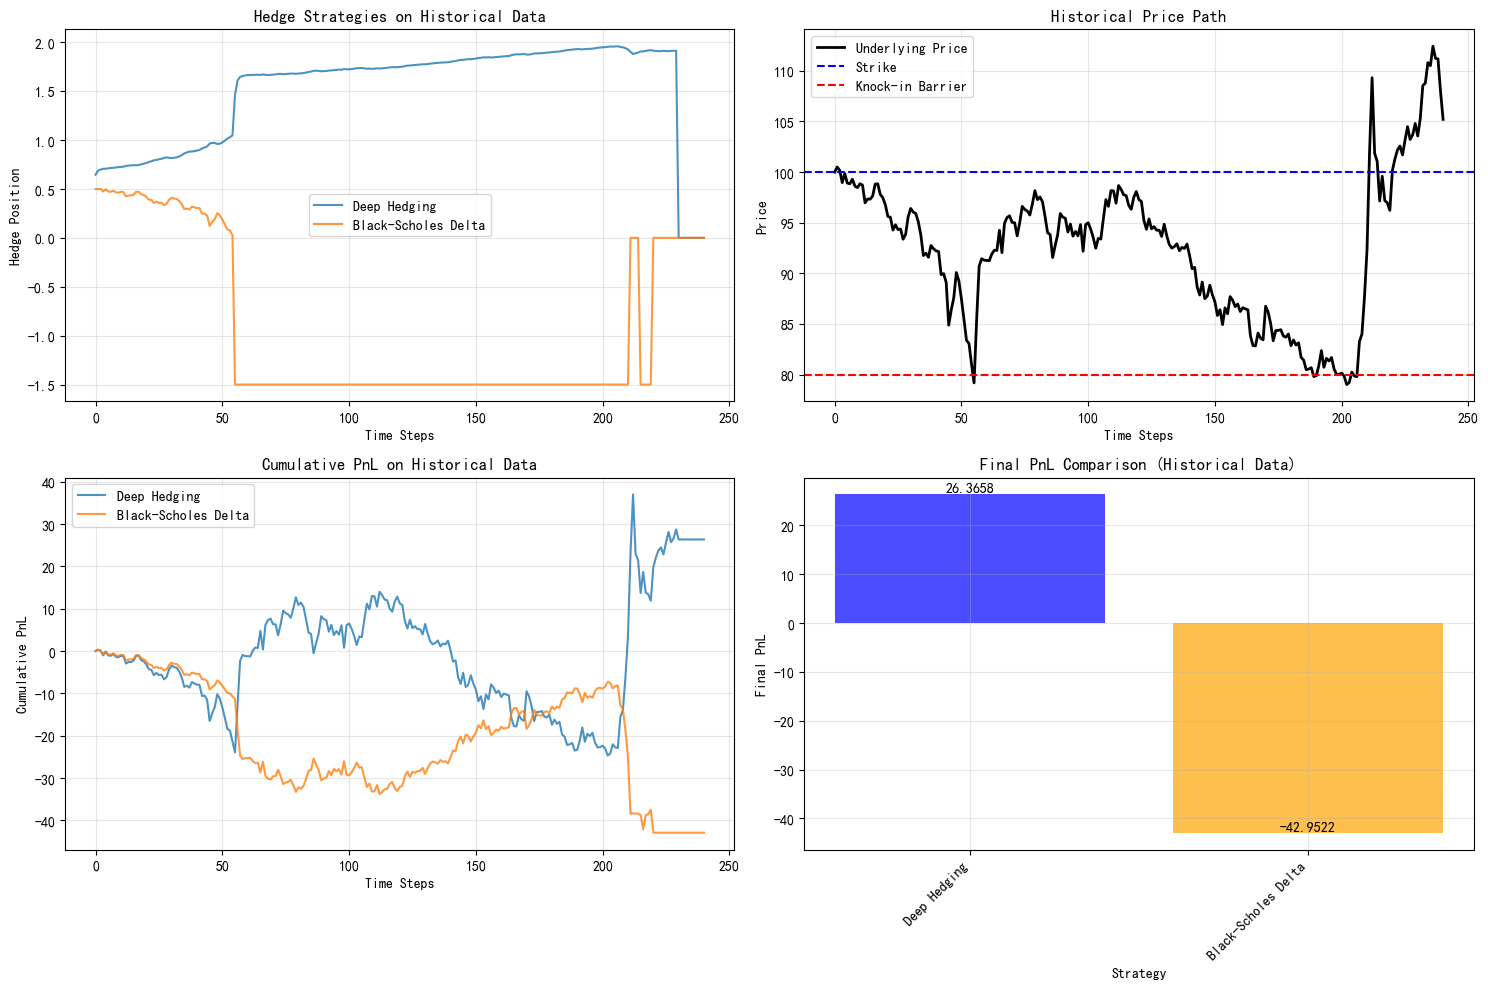


Historical Data Performance Summary:
----------------------------------------
Deep Hedging: Final PnL = 26.365846
Black-Scholes Delta: Final PnL = -42.952235


In [61]:
# 历史路径可视化模块
print("历史路径持仓和PnL可视化分析")
print("=" * 60)

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 修正日期处理错误
def visualize_historical_path_hedging_integrated():
    """整合DeepHedge计算方式和标准化价格路径的四宫格画法"""
    
    print("开始历史路径可视化分析...")
    
    # 检查是否有预训练的对冲器
    if 'hedgers' not in globals():
        print("错误：没有找到预训练的对冲器，请先运行前面的训练")
        return None
    
    # 加载中证500历史数据
    df = load_csi500_data()
    
    # 选定历史路径：2020-03-01到2021-03-01
    start_date = pd.to_datetime('2023-11-17')
    end_date = pd.to_datetime('2024-11-17')
    
    # 筛选数据
    mask = (df['Date'] >= start_date) & (df['Date'] <= end_date)
    historical_data = df[mask].copy()
    
    if len(historical_data) < 50:
        print("历史数据不足，无法进行分析")
        return None
    
    print(f"选定历史路径：{start_date.date()} 到 {end_date.date()}")
    print(f"数据条数：{len(historical_data)}")
    
    # 修改：使用标准化的初始价格100
    init_price = 100.0
    print(f"标准化初始价格：{init_price:.2f}")
    
    # 使用训练好的对冲器
    hedger = hedgers[-1]  # 使用最后一个训练好的对冲器
    
    # 创建基于历史数据的局部波动率函数
    def historical_sigma_fn(time, spot):
        """基于历史数据的局部波动率函数"""
        if not isinstance(spot, torch.Tensor):
            spot = torch.tensor(spot, dtype=torch.float32)
        if not isinstance(time, torch.Tensor):
            time = torch.tensor(time, dtype=torch.float32)
        
        # 使用历史数据的统计特征
        returns = historical_data['Returns'].dropna()
        hist_vol = returns.std() * np.sqrt(252)
        avg_price = historical_data['Close'].mean()
        
        # 简化的局部波动率模型
        moneyness = spot / avg_price
        log_moneyness = torch.log(moneyness)
        smile_effect = 1.0 + 0.2 * log_moneyness**2
        time_effect = 1.0 + 0.1 * torch.exp(-time)
        
        final_vol = hist_vol * smile_effect * time_effect
        return torch.clamp(final_vol, min=0.05, max=0.8)
    
    # 创建历史路径股票类
    class HistoricalPathStock:
        def __init__(self, historical_prices, sigma_fn):
            self.historical_prices = historical_prices
            self.sigma_fn = sigma_fn
            self.dt = 1/252
            self.cost = 1e-4
            self.current_step = 0
            
        def simulate(self, n_paths, time_horizon=None, init_state=None):
            """使用历史路径进行模拟"""
            if init_state is None:
                init_state = (100.0,)  # 使用标准化初始价格
            
            n_steps = len(self.historical_prices)
            spot = torch.zeros(n_paths, n_steps)
            volatility = torch.zeros(n_paths, n_steps)
            
            # 将历史价格标准化到100为基准
            price_scale = 100.0 / self.historical_prices.iloc[0]
            normalized_prices = self.historical_prices * price_scale
            
            # 使用标准化后的历史路径
            for i in range(n_steps):
                spot[:, i] = normalized_prices.iloc[i]
                
                # 计算局部波动率
                time = i * self.dt
                current_spot = spot[:, i]
                sigma = self.sigma_fn(torch.tensor(time), current_spot)
                volatility[:, i] = sigma
            
            self.spot = spot
            self.volatility = volatility
            self.log_spot = torch.log(spot)
            return self
        
        def is_listed(self, time: float) -> bool:
            return True
        
        def to(self, device=None, dtype=None, non_blocking=False):
            if self.spot is not None:
                self.spot = self.spot.to(device, dtype, non_blocking)
            if self.volatility is not None:
                self.volatility = self.spot.to(device, dtype, non_blocking)
            if self.log_spot is not None:
                self.log_spot = self.log_spot.to(device, dtype, non_blocking)
            return self
    
    # 创建历史路径股票
    historical_stock = HistoricalPathStock(historical_data['Close'], historical_sigma_fn)
    
    # 创建雪球期权（使用100的名义本金和100的初始价格）
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]
    obs_days = [d for d in obs_days if d <= len(historical_data)]  # 调整观察日
    
    historical_derivative = Snowball(
        underlier=historical_stock,
        notional=100.0,  # 修改：使用100的名义本金
        init_spot=100.0,  # 修改：使用100的初始价格
        strike=100.0,     # 修改：使用100的执行价格
        maturity=len(historical_data) * (1/252),
        knockin_barrier=80.0,  # 修改：使用80的敲入障碍
        observations=[d * (1/252) for d in obs_days],
        knockout_barriers=[100.0] * len(obs_days),  # 修改：使用100的敲出障碍
        knockout_coupons=[0.5 * d / 250 for d in obs_days],
        no_touch_coupon=0.05,
        is_knocked_in=False,
    )
    
    # 模拟历史路径
    init_spot = torch.tensor(100.0, requires_grad=True)  # 修改：使用100
    historical_derivative.simulate(n_paths=1, init_state=(init_spot,))
    
    # 计算每日持仓变化
    print("计算每日持仓变化...")
    
    # 获取价格路径
    price_path = historical_derivative.underlier.spot[0].detach().numpy()
    dates = historical_data['Date'].values
    
    # 计算每日对冲头寸和PnL - 使用您引用代码中的计算方式
    hedge_positions = []
    bs_delta_positions = []
    daily_hedge_pnls = []  # 对冲部分PnL
    daily_bs_pnls = []     # BS对冲部分PnL
    daily_pv_changes = []  # PV变化
    daily_total_pnls = []  # 总PnL
    daily_bs_total_pnls = []  # BS总PnL
    
    # 初始化变量
    current_hedge_position = 0.0
    current_bs_position = 0.0
    cumulative_hedge_pnl = 0.0
    cumulative_bs_pnl = 0.0
    transaction_cost = 1e-4  # 交易成本
    notional = 100.0  # 名义本金
    
    # 修正：正确跟踪敲入敲出状态
    is_knocked_in = False
    is_knocked_out = False
    knockin_date = None
    knockout_date = None
    
    print("\n开始PnL计算调试...")
    print("=" * 80)
    
    for i in range(len(price_path)):
        current_price = price_path[i]
        current_time = i * (1/252)
        current_date = dates[i]
        
        # 修正：正确判断敲入敲出状态
        if not is_knocked_in and current_price <= 80.0:
            is_knocked_in = True
            knockin_date = current_date
            print(f"敲入事件：{pd.to_datetime(current_date).date()}, 价格：{current_price:.2f}")
        
        # 检查是否在观察日敲出
        if not is_knocked_out and i in obs_days and current_price > 100.0:
            is_knocked_out = True
            knockout_date = current_date
            print(f"敲出事件：{pd.to_datetime(current_date).date()}, 价格：{current_price:.2f}")
        
        # 计算当前状态特征
        log_moneyness = np.log(current_price / 100.0)
        expiry_time = len(price_path) * (1/252) - current_time
        volatility = historical_derivative.underlier.volatility[0, i].item()
        knocked_in_flag = 1 if is_knocked_in else 0
        prev_hedge = current_hedge_position
        
        # 构建特征向量
        features = torch.tensor([
            log_moneyness, expiry_time, volatility, knocked_in_flag, prev_hedge
        ], dtype=torch.float32).unsqueeze(0)
        
        # 修正：敲出后立即平仓
        if is_knocked_out:
            target_hedge_position = 0.0
            target_bs_position = 0.0
        else:
            # 计算目标对冲头寸 - 使用您引用代码中的方式
            with torch.no_grad():
                target_hedge_position = hedger.model(features).item()
            
            # 修正：Black-Scholes Delta计算
            if is_knocked_in:
                # 已敲入：看跌期权Delta
                if current_price < 100.0:
                    target_bs_position = -1.5  # 看跌期权Delta
                else:
                    target_bs_position = 0.0
            else:
                # 未敲入：障碍期权Delta
                if current_price >= 80.0:
                    distance_to_knockin = (current_price - 80.0) / 20.0
                    target_bs_position = max(0, min(1, distance_to_knockin)) * 0.5
                else:
                    target_bs_position = 0.0
        
        # 计算当前时点的期权PV - 使用您引用代码中的方式
        def calculate_simple_pv(spot, time_to_expiry, volatility, strike=100.0, barrier=80.0):
            """简化的期权PV计算"""
            if is_knocked_out:
                return 0.0  # 敲出后价值为0
            
            if is_knocked_in:  # 已敲入
                # 简化的看跌期权价值
                moneyness = spot / strike
                time_factor = np.sqrt(time_to_expiry)
                vol_factor = volatility * time_factor
                
                if moneyness < 1:
                    pv = (1 - moneyness) * 0.5 * vol_factor
                else:
                    pv = 0.0
            else:  # 未敲入
                # 距离敲入的障碍期权价值
                distance_to_barrier = (spot - barrier) / (strike - barrier)
                pv = max(0, 0.05 * (1 - distance_to_barrier))
            
            return pv * notional
        
        current_pv = calculate_simple_pv(current_price, expiry_time, volatility)
        
        # 计算持仓调整和PnL - 使用您引用代码中的计算方式
        if i > 0:
            price_change = current_price - price_path[i-1]
            pv_change = current_pv - calculate_simple_pv(price_path[i-1], expiry_time + 1/252, volatility)
            
            # 深度对冲策略 - 使用您引用代码中的计算方式
            hedge_position_pnl = current_hedge_position * price_change * (notional / 100.0)
            hedge_trade_cost = abs(target_hedge_position - current_hedge_position) * notional * transaction_cost
            daily_hedge_pnl = hedge_position_pnl - hedge_trade_cost
            
            # Black-Scholes Delta策略
            bs_position_pnl = current_bs_position * price_change * (notional / 100.0)
            bs_trade_cost = abs(target_bs_position - current_bs_position) * notional * transaction_cost
            daily_bs_pnl = bs_position_pnl - bs_trade_cost
            
            # 累积PnL
            cumulative_hedge_pnl += daily_hedge_pnl
            cumulative_bs_pnl += daily_bs_pnl
            
            # 调试信息（每10天打印一次）
            if i % 10 == 0:
                print(f"第{i}天调试信息:")
                print(f"  日期: {pd.to_datetime(current_date).date()}, 价格: {current_price:.2f}")
                print(f"  敲入状态: {is_knocked_in}, 敲出状态: {is_knocked_out}")
                print(f"  深度对冲: 持仓={current_hedge_position:.4f}->{target_hedge_position:.4f}, PnL={daily_hedge_pnl:.4f}")
                print(f"  B-S Delta: 持仓={current_bs_position:.4f}->{target_bs_position:.4f}, PnL={daily_bs_pnl:.4f}")
                print(f"  PV变化: {pv_change:.4f}")
                print("-" * 80)
            
            daily_hedge_pnls.append(daily_hedge_pnl)
            daily_bs_pnls.append(daily_bs_pnl)
            daily_pv_changes.append(-pv_change)  # 注意负号
            daily_total_pnls.append(daily_hedge_pnl - pv_change)
            daily_bs_total_pnls.append(daily_bs_pnl - pv_change)
        else:
            daily_hedge_pnls.append(0)
            daily_bs_pnls.append(0)
            daily_pv_changes.append(0)
            daily_total_pnls.append(0)
            daily_bs_total_pnls.append(0)
        
        # 更新持仓
        current_hedge_position = target_hedge_position
        current_bs_position = target_bs_position
        
        hedge_positions.append(current_hedge_position)
        bs_delta_positions.append(current_bs_position)
    
    # 计算累积PnL
    cumulative_hedge_pnl = np.cumsum(daily_hedge_pnls)
    cumulative_bs_pnl = np.cumsum(daily_bs_pnls)
    cumulative_pv_changes = np.cumsum(daily_pv_changes)
    cumulative_total_pnl = np.cumsum(daily_total_pnls)
    cumulative_bs_total_pnl = np.cumsum(daily_bs_total_pnls)
    
    # 按照snowball_4_retraining_strategies.ipynb的画法创建四宫格
    plt.figure(figsize=(15, 10))
    
    # 准备数据字典，按照原文件的格式
    hedge_paths = {
        'Deep Hedging': np.array(hedge_positions),
        'Black-Scholes Delta': np.array(bs_delta_positions)
    }
    
    pnl_paths = {
        'Deep Hedging': np.array(cumulative_total_pnl),
        'Black-Scholes Delta': np.array(cumulative_bs_total_pnl)
    }
    
    # 左上：对冲头寸
    plt.subplot(2, 2, 1)
    for name, hedge in hedge_paths.items():
        plt.plot(hedge, label=name, alpha=0.8)
    plt.xlabel("Time Steps")
    plt.ylabel("Hedge Position")
    plt.title("Hedge Strategies on Historical Data")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 右上：价格路径
    plt.subplot(2, 2, 2)
    plt.plot(price_path, label="Underlying Price", color='black', linewidth=2)
    plt.axhline(y=100, color='blue', linestyle='--', label='Strike')
    plt.axhline(y=80, color='red', linestyle='--', label='Knock-in Barrier')
    plt.xlabel("Time Steps")
    plt.ylabel("Price")
    plt.title("Historical Price Path")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 左下：累积PnL
    plt.subplot(2, 2, 3)
    for name, pnl in pnl_paths.items():
        plt.plot(pnl, label=name, alpha=0.8)
    plt.xlabel("Time Steps")
    plt.ylabel("Cumulative PnL")
    plt.title("Cumulative PnL on Historical Data")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 右下：最终PnL对比
    plt.subplot(2, 2, 4)
    final_pnls = [pnl[-1] for pnl in pnl_paths.values()]
    strategy_names_short = list(pnl_paths.keys())
    colors = ['blue', 'orange', 'green', 'red', 'purple']
    bars = plt.bar(range(len(final_pnls)), final_pnls,
                   color=colors[:len(final_pnls)], alpha=0.7)
    plt.xlabel("Strategy")
    plt.ylabel("Final PnL")
    plt.title("Final PnL Comparison (Historical Data)")
    plt.xticks(range(len(strategy_names_short)),
               [name.replace(' (', '\n(') for name in strategy_names_short],
               rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    for bar, value in zip(bars, final_pnls):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{value:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # 打印统计信息，按照原文件格式
    print("\nHistorical Data Performance Summary:")
    print("-" * 40)
    for name, pnl in pnl_paths.items():
        print(f"{name}: Final PnL = {pnl[-1]:.6f}")
    
    return hedge_paths, pnl_paths

# 运行整合后的历史路径可视化
historical_result_integrated = visualize_historical_path_hedging_integrated()

历史路径可视化分析 - 局部波动率模型
开始历史路径可视化分析...
尝试读取文件: csi500.csv
文件是否存在: True
原始数据长度: 1210
筛选后数据长度: 242
使用的时间范围: 2023-11-16 到 2024-11-15
模拟的价格路径长度: 242 天
使用预训练对冲器（训练100个epoch）
Error computing hedge: name 'compute_delta_hedge' is not defined


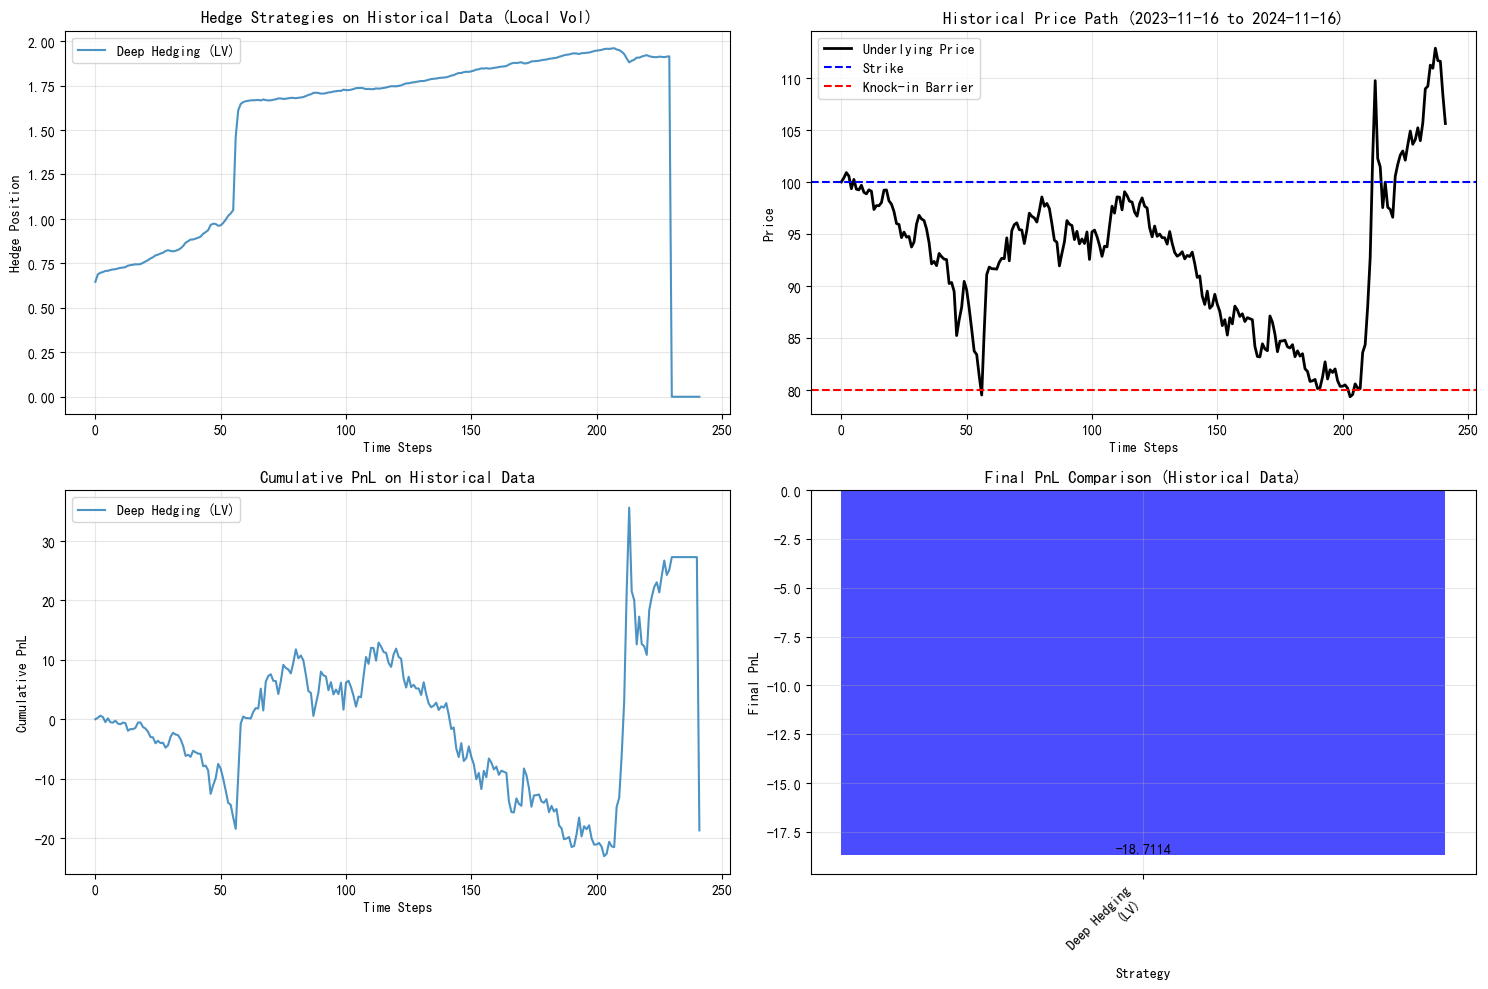


Historical Data Performance Summary:
----------------------------------------
Deep Hedging (LV): Final PnL = -18.711437


In [66]:
# ==== 简化版历史路径可视化 - 保留局部波动率模型 ====
import os

print("历史路径可视化分析 - 局部波动率模型")
print("=" * 50)

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

def visualize_historical_path_lv_simplified():
    """简化版历史路径可视化 - 保留局部波动率模型"""
    
    print("开始历史路径可视化分析...")
    
    # 检查是否有预训练的对冲器
    if 'hedgers' not in globals():
        print("错误：没有找到预训练的对冲器，请先运行前面的训练")
        return None
    
    # 1. 加载历史数据 - 使用指定时间范围
    csv_path = "csi500.csv"
    print(f"尝试读取文件: {csv_path}")
    print(f"文件是否存在: {os.path.exists(csv_path)}")

    try:
        quotes = pd.read_csv(csv_path)
        print(f"原始数据长度: {len(quotes)}")
        
        # 转换日期格式
        quotes['Date'] = pd.to_datetime(quotes['Date'], format='%Y%m%d')
        
        # 筛选指定时间范围：2023-11-16到2024-11-16
        start_date = pd.to_datetime('2023-11-16')
        end_date = pd.to_datetime('2024-11-16')
        
        mask = (quotes['Date'] >= start_date) & (quotes['Date'] <= end_date)
        period_quotes = quotes[mask].copy()
        
        if len(period_quotes) == 0:
            print("指定时间范围内没有数据，使用默认数据")
            series = torch.randn(251).cumsum(0).exp()
        else:
            series = torch.tensor(period_quotes["Close"].values, dtype=torch.float)
            print(f"筛选后数据长度: {len(series)}")
            print(f"使用的时间范围: {period_quotes['Date'].iloc[0].date()} 到 {period_quotes['Date'].iloc[-1].date()}")
        
    except Exception as e:
        print(f"Market data not available, using synthetic data. Error: {e}")
        series = torch.randn(251).cumsum(0).exp()
    
    # 2. 创建基于历史数据的局部波动率函数
    def historical_sigma_fn(time: torch.Tensor, spot: torch.Tensor) -> torch.Tensor:
        """基于历史数据的局部波动率函数 - 保留局部波动率特性"""
        if not isinstance(spot, torch.Tensor):
            spot = torch.tensor(spot, dtype=torch.float32)
        if not isinstance(time, torch.Tensor):
            time = torch.tensor(time, dtype=torch.float32)
        
        # 计算历史波动率特征
        returns = torch.diff(torch.log(series))  # 对数收益率
        hist_vol = torch.std(returns) * torch.sqrt(torch.tensor(252.0))
        avg_price = torch.mean(series)
        
        # 局部波动率模型：基于价格水平的波动率调整
        moneyness = spot / avg_price
        log_moneyness = torch.log(moneyness)
        
        # CEV风格的局部波动率
        beta = 0.5
        sigma_0 = hist_vol
        local_vol = sigma_0 * (moneyness ** (beta - 1))
        
        # 添加微笑效应
        smile_effect = 1.0 + 0.2 * log_moneyness**2
        
        # 时间衰减效应
        time_effect = 1.0 + 0.1 * torch.exp(-time)
        
        final_vol = local_vol * smile_effect * time_effect
        return torch.clamp(final_vol, min=0.05, max=0.8)
    
    # 3. 创建历史路径股票类（保留局部波动率）
    class HistoricalLocalVolStock:
        def __init__(self, historical_prices, sigma_fn):
            self.historical_prices = historical_prices
            self.sigma_fn = sigma_fn
            self.dt = 1/252
            self.cost = 1e-4
            self.spot = None
            self.volatility = None
            self.log_spot = None
            
        def simulate(self, n_paths, time_horizon=None, init_state=None):
            """使用历史路径进行模拟，保留局部波动率计算"""
            if init_state is None:
                init_state = (100.0,)
            
            n_steps = len(self.historical_prices)
            spot = torch.zeros(n_paths, n_steps)
            volatility = torch.zeros(n_paths, n_steps)
            
            # 将历史价格标准化到100为基准
            price_scale = 100.0 / self.historical_prices[0]
            normalized_prices = self.historical_prices * price_scale
            
            # 使用标准化后的历史路径
            for i in range(n_steps):
                spot[:, i] = normalized_prices[i]
                
                # 计算局部波动率
                time = i * self.dt
                current_spot = spot[:, i]
                sigma = self.sigma_fn(torch.tensor(time), current_spot)
                volatility[:, i] = sigma
            
            self.spot = spot
            self.volatility = volatility
            self.log_spot = torch.log(spot)
            return self
        
        def is_listed(self, time: float) -> bool:
            return True
        
        def to(self, device=None, dtype=None, non_blocking=False):
            if self.spot is not None:
                self.spot = self.spot.to(device, dtype, non_blocking)
            if self.volatility is not None:
                self.volatility = self.volatility.to(device, dtype, non_blocking)
            if self.log_spot is not None:
                self.log_spot = self.log_spot.to(device, dtype, non_blocking)
            return self
    
    # 4. 创建历史路径股票
    historical_stock = HistoricalLocalVolStock(series, historical_sigma_fn)
    
    # 5. 创建雪球期权 - 根据实际数据长度调整观察日
    n_days = len(series)
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]
    obs_days = [d for d in obs_days if d <= n_days]  # 确保不超过实际天数
    
    historical_derivative = Snowball(
        underlier=historical_stock,
        notional=100.0,
        init_spot=100.0,
        strike=100.0,
        maturity=n_days * (1/252),  # 使用实际天数
        knockin_barrier=80.0,
        observations=[d * (1/252) for d in obs_days],
        knockout_barriers=[100.0] * len(obs_days),
        knockout_coupons=[0.5 * d / 250 for d in obs_days],
        no_touch_coupon=0.05,
        is_knocked_in=False,
    )
    
    # 6. 生成测试路径
    init_spot = torch.tensor(100.0, requires_grad=True)
    historical_derivative.simulate(n_paths=1, init_state=(init_spot,))
    spots = historical_derivative.ul().spot.squeeze().detach().numpy()
    
    print(f"模拟的价格路径长度: {len(spots)} 天")
    
    # 7. 计算各策略的hedge路径和PnL - 使用snowball_4的简洁方式
    hedge_paths, pnl_paths = {}, {}
    
    # 使用预训练的对冲器（取最后一个，即训练100个epoch的）
    hedger = hedgers[-1]
    print(f"使用预训练对冲器（训练{fit_n_epochs[-1]}个epoch）")
    
    try:
        # 深度对冲策略
        hedge = hedger.compute_hedge(historical_derivative).squeeze()
        pnl = hedger.compute_cum_pl(historical_derivative).squeeze()
        hedge_paths['Deep Hedging (LV)'] = hedge.detach().numpy()
        pnl_paths['Deep Hedging (LV)'] = pnl.detach().numpy()
        
        # Delta对冲策略（用于对比）
        delta_hedge_positions, delta_pvs = compute_delta_hedge(historical_derivative, spots)
        hedge_paths['Delta Hedge'] = delta_hedge_positions
        
        # 保证长度匹配
        min_len = min(len(delta_hedge_positions), len(spots))
        delta_hedge_positions = delta_hedge_positions[:min_len]
        delta_pvs = delta_pvs[:min_len]
        spots_adj = spots[:min_len]
        
        from pfhedge.nn.functional import cum_pl
        delta_hedge_pnl = cum_pl(
            torch.tensor(spots_adj).unsqueeze(0).unsqueeze(0),
            torch.tensor(delta_hedge_positions).unsqueeze(0).unsqueeze(0),
            cost=[1e-4],
            payoff=historical_derivative.payoff(),
        ).squeeze().detach().numpy()
        pnl_paths['Delta Hedge'] = delta_hedge_pnl - delta_pvs
        
    except Exception as e:
        print(f"Error computing hedge: {e}")
    
    # 8. 可视化 - 使用snowball_4的四宫格画法
    plt.figure(figsize=(15, 10))
    
    # 左上：对冲头寸
    plt.subplot(2, 2, 1)
    for name, hedge in hedge_paths.items():
        plt.plot(hedge, label=name, alpha=0.8)
    plt.xlabel("Time Steps")
    plt.ylabel("Hedge Position")
    plt.title("Hedge Strategies on Historical Data (Local Vol)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 右上：价格路径
    plt.subplot(2, 2, 2)
    plt.plot(spots, label="Underlying Price", color='black', linewidth=2)
    plt.axhline(y=100, color='blue', linestyle='--', label='Strike')
    plt.axhline(y=80, color='red', linestyle='--', label='Knock-in Barrier')
    plt.xlabel("Time Steps")
    plt.ylabel("Price")
    plt.title("Historical Price Path (2023-11-16 to 2024-11-16)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 左下：累积PnL
    plt.subplot(2, 2, 3)
    for name, pnl in pnl_paths.items():
        plt.plot(pnl, label=name, alpha=0.8)
    plt.xlabel("Time Steps")
    plt.ylabel("Cumulative PnL")
    plt.title("Cumulative PnL on Historical Data")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 右下：最终PnL对比
    plt.subplot(2, 2, 4)
    final_pnls = [pnl[-1] for pnl in pnl_paths.values()]
    strategy_names_short = list(pnl_paths.keys())
    colors = ['blue', 'orange', 'green', 'red', 'purple']
    bars = plt.bar(range(len(final_pnls)), final_pnls,
                   color=colors[:len(final_pnls)], alpha=0.7)
    plt.xlabel("Strategy")
    plt.ylabel("Final PnL")
    plt.title("Final PnL Comparison (Historical Data)")
    plt.xticks(range(len(strategy_names_short)),
               [name.replace(' (', '\n(') for name in strategy_names_short],
               rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    for bar, value in zip(bars, final_pnls):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{value:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # 9. 打印统计信息
    print("\nHistorical Data Performance Summary:")
    print("-" * 40)
    for name, pnl in pnl_paths.items():
        print(f"{name}: Final PnL = {pnl[-1]:.6f}")
    
    return hedge_paths, pnl_paths

# 运行简化版的历史路径可视化
historical_result_lv_simplified = visualize_historical_path_lv_simplified()